In [7]:
# Imports, paths, nucleus geometry, base fire data
import os, sys
sys.path.insert(0, os.path.abspath('..'))          # repo root on the import path

import ee
import geemap
import pandas as pd
import col_amazon_fire_utils as utils

ee = utils.initialize_ee()
nucleus_geom = utils.get_nucleus_geometry()

DATA = '../datasets/'                               # central folder for cached tables

# Burned area: load from CSV if present, else compute once and save
burned_csv = DATA + 'burned_df.csv'
if os.path.exists(burned_csv):
    burned_df = pd.read_csv(burned_csv)
    print("Loaded burned_df from CSV.")
else:
    burned_df = utils.get_burned_df(nucleus_geom)
    burned_df.to_csv(burned_csv, index=False)
    print("Recomputed and saved burned_df.")

print(burned_df.head())

Loaded burned_df from CSV.
   year  burned_area_ha
0  2001    76977.850290
1  2002    48981.877208
2  2003    56097.455116
3  2004   441596.524962
4  2005    58045.684765


In [8]:
# Social variables: Land Use and Land Cover (LULC) data from MapBiomas Colombia Collection 3.0

mb_lulc = ee.Image('projects/mapbiomas-colombia/assets/LULC/COLECCION3/INTEGRACION/COLOMBIA-1')

# Group the detailed MapBiomas codes into 7 thematic classes
#   1 Forest | 2 Natural non-forest (savanna) | 3 Pasture
#   4 Agriculture | 5 Mosaic | 6 Water | 7 Other / built / mining
from_codes = [3, 6, 5,   4, 11, 12, 13,   15,   18, 35,   21,   33,   9, 23, 24, 29, 30, 68]
to_groups  = [1, 1, 1,   2,  2,  2,  2,    3,    4,  4,    5,    6,    7,  7,  7,  7,  7,  7]

group_names   = {1:'forest', 2:'natural_nonforest', 3:'pasture',
                 4:'agriculture', 5:'mosaic', 6:'water', 7:'other'}
group_palette = ['1f8d49', 'd6bc74', 'edde8e', 'e974ed', 'ffefc3', '2532e4', 'b2b2b2']

print("LULC bands available:", mb_lulc.bandNames().size().getInfo(), "years")

LULC bands available: 40 years


In [9]:
# Social/infrastructure vector assets (uploaded to GEE)
# Parks : Ministerio de Ambiente y Desarrollo Sostenible (MADS) - 2026
# Roads : INVIAS - Colombia (https://www.invias.gov.co/) - 2026
# rivers : IGAC - Colombia (https://www.igac.gov.co/) - 1998
# coca cultivation : Ministerio de Justicia (https://www.unodc.org/) - 2026

base = 'projects/col-amazon-fire-susceptibility/assets/'

layers = {
    'parks':  ee.FeatureCollection(base + 'national_natural_parks'),
    'roads':  ee.FeatureCollection(base + 'roads'),
    'rivers': ee.FeatureCollection(base + 'rivers'),
    'coca':   ee.FeatureCollection(base + 'coca_cultivation_v2'),
}

# Quick health check: count features and list attributes
for name, fc in layers.items():
    print(f"{name:8s}: {fc.size().getInfo()} features | "
          f"attrs: {fc.first().propertyNames().getInfo()[:6]} ...")

parks   : 1882 features | attrs: ['ap_id', 'territoria', 'fecha_regi', 'centroid_1', 'area_ha__2', 'area_ha__1'] ...
roads   : 657 features | attrs: ['distanciaf', 'territoria', 'ruta', 'categoria', 'fuente', 'globalid'] ...
rivers  : 900 features | attrs: ['LON_2010', 'LENGTH', 'VERIF', 'Longi', 'system:index', 'NAME'] ...
coca    : 43371 features | attrs: ['coca_2018', 'coca_2019', 'coca_2016', 'coca_2017', 'coca_2010', 'coca_2011'] ...


In [10]:
# 1. Annual land-cover area per class (2001–2024) for the nucleus geometry

lulc_csv = DATA + 'lulc_area_df.csv'

if os.path.exists(lulc_csv):
    lulc_area_df = pd.read_csv(lulc_csv)
    print("Loaded lulc_area_df from CSV.")
else:
    def lulc_areas(year):
        grouped = (mb_lulc.select(f'classification_{year}') 
                   .clip(nucleus_geom).remap(from_codes, to_groups, 0).rename('group')) 
        area_ha = ee.Image.pixelArea().divide(1e4).addBands(grouped) 
        out = area_ha.reduceRegion(
            reducer=ee.Reducer.sum().group(groupField=1, groupName='group'),
            geometry=nucleus_geom, scale=100, maxPixels=1e13, tileScale=4).getInfo()
        row = {'year': year}
        for g in out['groups']:
            if g['group'] in group_names:
                row[group_names[g['group']] + '_ha'] = g['sum']
        return row

    records = []
    for year in range(2001, 2025):                 # MapBiomas Col.3 ends in 2024
        print(f"LULC areas {year}...", end=" ")
        records.append(lulc_areas(year)); print("done")

    lulc_area_df = pd.DataFrame(records).fillna(0)
    lulc_area_df.to_csv(lulc_csv, index=False)
    print("Computed and saved lulc_area_df.")

print(lulc_area_df.round(0))

LULC areas 2001... done
LULC areas 2002... done
LULC areas 2003... done
LULC areas 2004... done
LULC areas 2005... done
LULC areas 2006... done
LULC areas 2007... done
LULC areas 2008... done
LULC areas 2009... done
LULC areas 2010... done
LULC areas 2011... done
LULC areas 2012... done
LULC areas 2013... done
LULC areas 2014... done
LULC areas 2015... done
LULC areas 2016... done
LULC areas 2017... done
LULC areas 2018... done
LULC areas 2019... done
LULC areas 2020... done
LULC areas 2021... done
LULC areas 2022... done
LULC areas 2023... done
LULC areas 2024... done
Computed and saved lulc_area_df.
    year  forest_ha  natural_nonforest_ha  mosaic_ha  water_ha  other_ha  \
0   2001  9315828.0              478381.0  1279096.0   96339.0    6834.0   
1   2002  9288274.0              473677.0  1309396.0   96795.0    7826.0   
2   2003  9234236.0              474610.0  1361897.0   97935.0    8530.0   
3   2004  9192510.0              482719.0  1399599.0   96093.0    5730.0   
4   2005  9

In [11]:
# Coca cultivation: annual area per year (2001–2023) for the nucleus geometry
coca_csv = DATA + 'coca_df.csv'

if os.path.exists(coca_csv):
    coca_df = pd.read_csv(coca_csv)
    print("Loaded coca_df from CSV.")
else:
    coca = layers['coca'].filterBounds(nucleus_geom)
    records = []
    for year in range(2001, 2024):                 # coca series: 2001–2023
        total = coca.aggregate_sum(f'coca_{year}').getInfo()   # already numeric
        records.append({'year': year, 'coca_ha': total})
        print(f"{year}: {total:,.0f} ha")
    coca_df = pd.DataFrame(records)
    coca_df.to_csv(coca_csv, index=False)
    print("Computed and saved coca_df.")

print(coca_df)

2001: 20,516 ha
2002: 16,636 ha
2003: 15,072 ha
2004: 9,786 ha
2005: 9,035 ha
2006: 9,557 ha
2007: 10,379 ha
2008: 6,539 ha
2009: 7,409 ha
2010: 3,827 ha
2011: 4,666 ha
2012: 3,958 ha
2013: 5,097 ha
2014: 8,293 ha
2015: 8,342 ha
2016: 10,219 ha
2017: 10,320 ha
2018: 8,646 ha
2019: 3,906 ha
2020: 2,907 ha
2021: 4,484 ha
2022: 6,213 ha
2023: 7,593 ha
Computed and saved coca_df.
    year       coca_ha
0   2001  20516.360000
1   2002  16635.730000
2   2003  15072.280000
3   2004   9786.070000
4   2005   9035.310000
5   2006   9557.130000
6   2007  10378.690000
7   2008   6539.490000
8   2009   7409.320000
9   2010   3826.580000
10  2011   4665.568000
11  2012   3957.602500
12  2013   5096.962300
13  2014   8293.022100
14  2015   8341.682291
15  2016  10219.380000
16  2017  10320.158291
17  2018   8645.735629
18  2019   3905.856833
19  2020   2906.574324
20  2021   4484.260000
21  2022   6212.800677
22  2023   7593.213326


In [12]:
# Final social map: infrastructure & coca vs. cumulative burned area
burned_all = (ee.ImageCollection('MODIS/061/MCD64A1')
              .filterDate('2001-01-01', '2025-12-31').select('BurnDate')
              .map(lambda i: i.gt(0)).max().selfMask().clip(nucleus_geom))

buf = nucleus_geom.buffer(10000)                   # 10 km margin for distance edges

Map = geemap.Map()
Map.centerObject(nucleus_geom, 8)

Map.addLayer(layers['parks'].filterBounds(buf).style(color='006d2c', fillColor='006d2c33'),
             {}, 'National parks')
Map.addLayer(layers['rivers'].filterBounds(buf).style(color='1f78b4', width=1), {}, 'Rivers')
Map.addLayer(layers['roads'].filterBounds(buf).style(color='999999', width=1.5), {}, 'Roads')
Map.addLayer(burned_all, {'palette': ['e31a1c']}, 'Burned 2001–2025', opacity=0.55)
Map.addLayer(nucleus_geom, {'color': 'black'}, 'Núcleo')

Map.add_legend(title='Infrastructure vs fire', legend_dict={
    'National parks':'#006d2c', 'Rivers':'#1f78b4', 'Roads':'#999999',
    'Burned 2001–2025':'#e31a1c'})
Map

Map(center=[1.1628459995751101, -73.35629583777123], controls=(WidgetControl(options=['position', 'transparent…

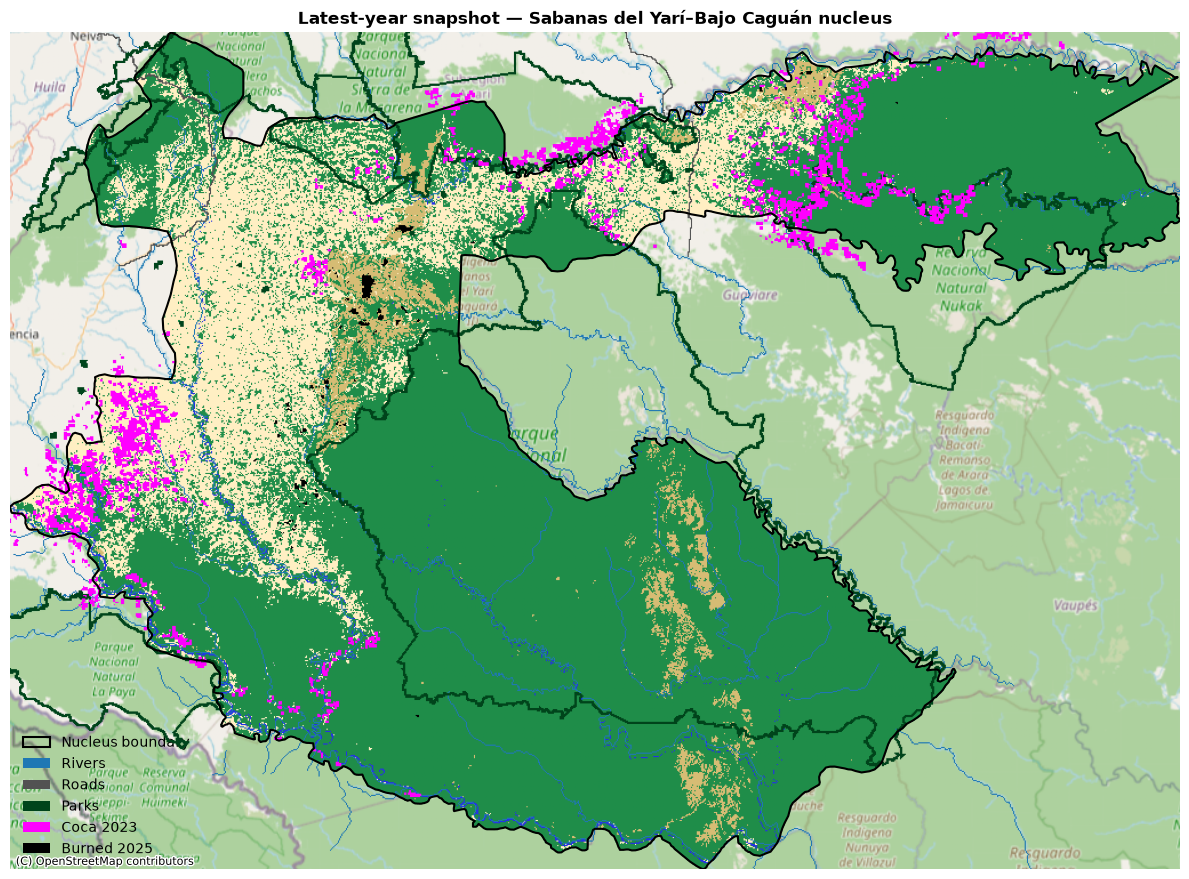

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as cx
from PIL import Image
import urllib.request, io

region = nucleus_geom.bounds()
buf    = nucleus_geom.buffer(10000)

# --- Build the composite (latest year of each layer) ---
lulc24 = (mb_lulc.select('classification_2024').clip(nucleus_geom)
          .remap(from_codes, to_groups, 0).selfMask())

coca23 = (layers['coca'].filterBounds(buf)
          .reduceToImage(['coca_2023'], ee.Reducer.first()))
coca23 = coca23.updateMask(coca23.gt(0))

burned25 = (ee.ImageCollection('MODIS/061/MCD64A1')
            .filterDate('2025-01-01','2025-12-31').select('BurnDate')
            .max().gt(0).selfMask().clip(nucleus_geom))

rivers_img = ee.Image(0).byte().paint(layers['rivers'].filterBounds(buf), 1, 1)
roads_img  = ee.Image(0).byte().paint(layers['roads'].filterBounds(buf), 1, 1)
parks_line = ee.Image(0).byte().paint(layers['parks'].filterBounds(buf), 1, 2)  # park outline

# Stack as coloured layers (bottom -> top)
composite = (lulc24.visualize(min=1, max=7, palette=group_palette)
             .blend(rivers_img.selfMask().visualize(palette=['1f78b4']))
             .blend(roads_img.selfMask().visualize(palette=['525252']))
             .blend(parks_line.selfMask().visualize(palette=['00441b']))
             .blend(coca23.visualize(palette=['ff00ff']))
             .blend(burned25.visualize(palette=['000000'])))

# --- Pull a static thumbnail via its URL (version-proof) ---
url = composite.getThumbURL({'region': region, 'dimensions': 1024, 'format': 'png'})
img = Image.open(io.BytesIO(urllib.request.urlopen(url).read()))

nucleus_bounds = nucleus_geom.bounds().getInfo()['coordinates'][0]
lon_min = min(p[0] for p in nucleus_bounds)
lon_max = max(p[0] for p in nucleus_bounds)
lat_min = min(p[1] for p in nucleus_bounds)
lat_max = max(p[1] for p in nucleus_bounds)

nucleus_coords = nucleus_geom.coordinates().getInfo()

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

cx.add_basemap(
    ax,
    crs='EPSG:4326',
    source=cx.providers.OpenStreetMap.Mapnik,
    zoom=8
)

ax.imshow(img, extent=[lon_min, lon_max, lat_min, lat_max], zorder=10)

if isinstance(nucleus_coords[0][0][0], list):
    for polygon in nucleus_coords:
        for ring in polygon:
            xs = [p[0] for p in ring]
            ys = [p[1] for p in ring]
            ax.plot(xs, ys, color='black', linewidth=1.5, zorder=11)
else:
    for ring in nucleus_coords:
        xs = [p[0] for p in ring]
        ys = [p[1] for p in ring]
        ax.plot(xs, ys, color='black', linewidth=1.5, zorder=11)

legend_handles = [
    Patch(facecolor='none', edgecolor='black', label='Nucleus boundary', linewidth=1.5),
    Patch(facecolor='#1f78b4', edgecolor='none', label='Rivers'),
    Patch(facecolor='#525252', edgecolor='none', label='Roads'),
    Patch(facecolor='#00441b', edgecolor='none', label='Parks'),
    Patch(facecolor='#ff00ff', edgecolor='none', label='Coca 2023'),
    Patch(facecolor='#000000', edgecolor='none', label='Burned 2025')
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=10, frameon=False)

ax.axis('off')
ax.set_title('Latest-year snapshot — Sabanas del Yarí–Bajo Caguán nucleus',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../datasets/latest_year_snapshot.png', dpi=200, bbox_inches='tight')
plt.show()


In [16]:
# Temporal correlations: land-cover change & coca vs. burned area
m = burned_df.merge(lulc_area_df, on='year').merge(coca_df, on='year', how='left').sort_values('year')

candidates = [('forest_ha','Forest'),
              ('mosaic_ha','Mosaic ag/pasture (frontier)'), #anthropogenic mosaic of agriculture and pasture
              ('agriculture_ha','Agriculture'),
              ('natural_nonforest_ha','Natural non-forest'),
              ('coca_ha','Coca')]

cols = [(c, lbl) for c, lbl in candidates if c in m.columns]

print(f"{'Variable':30s} {'raw r':>8s} {'Δ (detrended) r':>16s}")
for col, label in cols:
    sub    = m[['burned_area_ha', col]].dropna()
    r_raw  = sub['burned_area_ha'].corr(sub[col])
    r_diff = sub['burned_area_ha'].diff().corr(sub[col].diff())
    print(f"{label:30s} {r_raw:+8.2f} {r_diff:+16.2f}")

Variable                          raw r  Δ (detrended) r
Forest                            +0.13            -0.30
Mosaic ag/pasture (frontier)      -0.14            +0.30
Agriculture                       -0.15            +0.02
Natural non-forest                +0.27            +0.11
Coca                              +0.07            +0.14


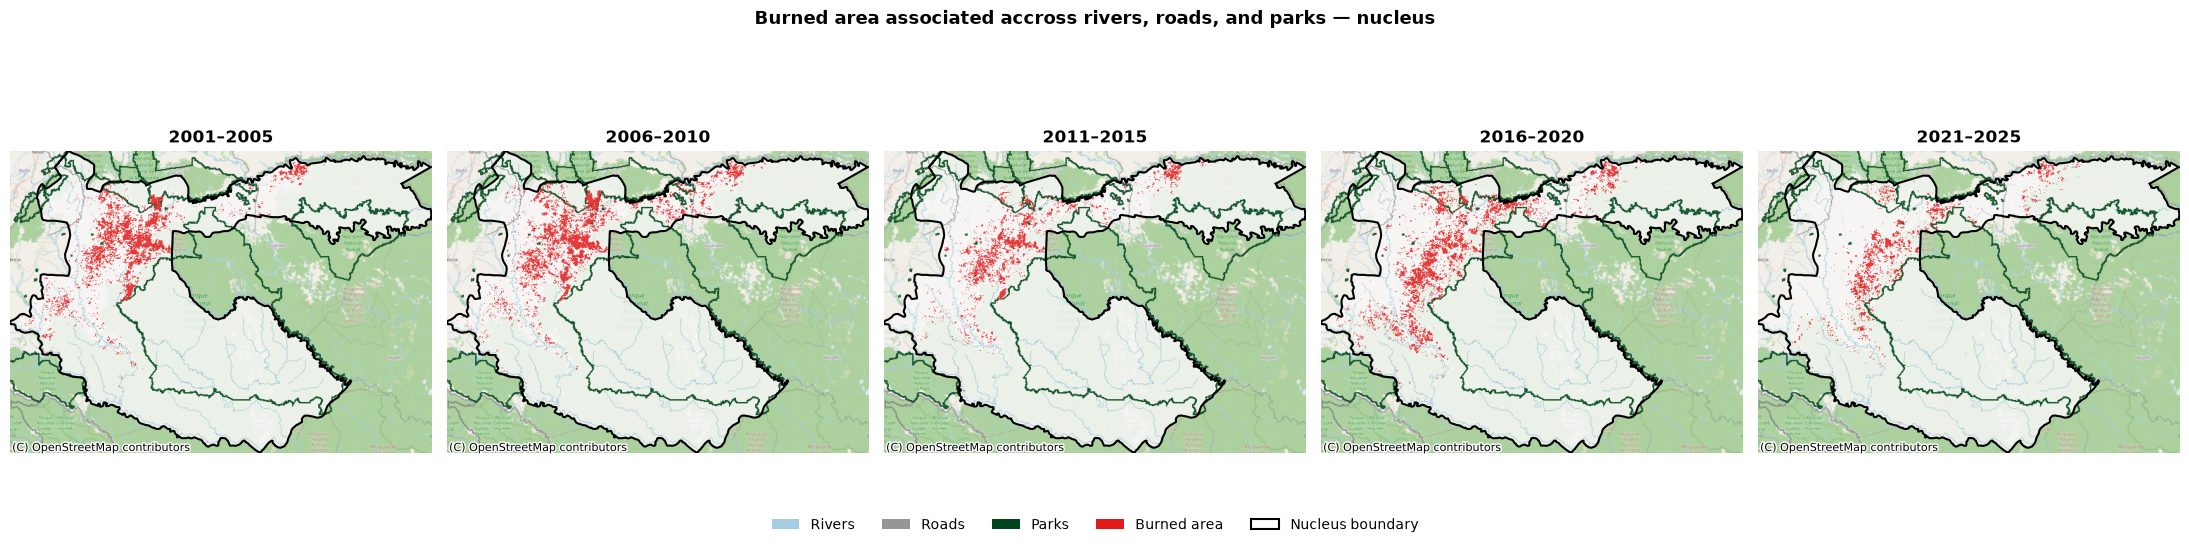

In [23]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as cx
from PIL import Image
import urllib.request, io

quintiles = [(2001,2005),(2006,2010),(2011,2015),(2016,2020),(2021,2025)]
region = nucleus_geom.bounds()
buf = nucleus_geom.buffer(10000)

rivers_img = ee.Image(0).byte().paint(layers['rivers'].filterBounds(buf), 1, 1)
roads_img  = ee.Image(0).byte().paint(layers['roads'].filterBounds(buf), 1, 1)
parks_line = ee.Image(0).byte().paint(layers['parks'].filterBounds(buf), 1, 2)

# numeric bounds for the basemap and overlay extents
nucleus_bounds = nucleus_geom.bounds().getInfo()['coordinates'][0]
lon_min = min(p[0] for p in nucleus_bounds)
lon_max = max(p[0] for p in nucleus_bounds)
lat_min = min(p[1] for p in nucleus_bounds)
lat_max = max(p[1] for p in nucleus_bounds)

nucleus_coords = nucleus_geom.coordinates().getInfo()

def quintile_thumb(y0, y1):
    burned = (ee.ImageCollection('MODIS/061/MCD64A1')
              .filterDate(f'{y0}-01-01', f'{y1}-12-31').select('BurnDate')
              .map(lambda i: i.gt(0)).max().selfMask().clip(nucleus_geom))
    comp = (ee.Image(1).clip(nucleus_geom).visualize(palette=['f7f7f7'])
            .blend(rivers_img.selfMask().visualize(palette=['a6cee3']))
            .blend(roads_img.selfMask().visualize(palette=['969696']))
            .blend(parks_line.selfMask().visualize(palette=['00441b']))
            .blend(burned.visualize(palette=['e31a1c'])))
    url = comp.getThumbURL({'region': region, 'dimensions': 600, 'format': 'png'})
    return Image.open(io.BytesIO(urllib.request.urlopen(url).read()))

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (y0, y1) in zip(axes, quintiles):
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)

    cx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=cx.providers.OpenStreetMap.Mapnik,
        zoom=8
    )

    ax.imshow(quintile_thumb(y0, y1), extent=[lon_min, lon_max, lat_min, lat_max], alpha=0.85, zorder=10)

    if isinstance(nucleus_coords[0][0][0], list):
        for polygon in nucleus_coords:
            for ring in polygon:
                xs = [p[0] for p in ring]
                ys = [p[1] for p in ring]
                ax.plot(xs, ys, color='black', linewidth=1.5, zorder=11)
    else:
        for ring in nucleus_coords:
            xs = [p[0] for p in ring]
            ys = [p[1] for p in ring]
            ax.plot(xs, ys, color='black', linewidth=1.5, zorder=11)

    ax.set_title(f'{y0}–{y1}', fontsize=12, fontweight='bold')
    ax.axis('off')

legend_handles = [
    Patch(facecolor='#a6cee3', edgecolor='none', label='Rivers'),
    Patch(facecolor='#969696', edgecolor='none', label='Roads'),
    Patch(facecolor='#00441b', edgecolor='none', label='Parks'),
    Patch(facecolor='#e31a1c', edgecolor='none', label='Burned area'),
    Patch(facecolor='none', edgecolor='black', label='Nucleus boundary', linewidth=1.5)
]
fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Burned area associated accross rivers, roads, and parks — nucleus', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../datasets/social_burned_quintiles.png', dpi=200, bbox_inches='tight')
plt.show()

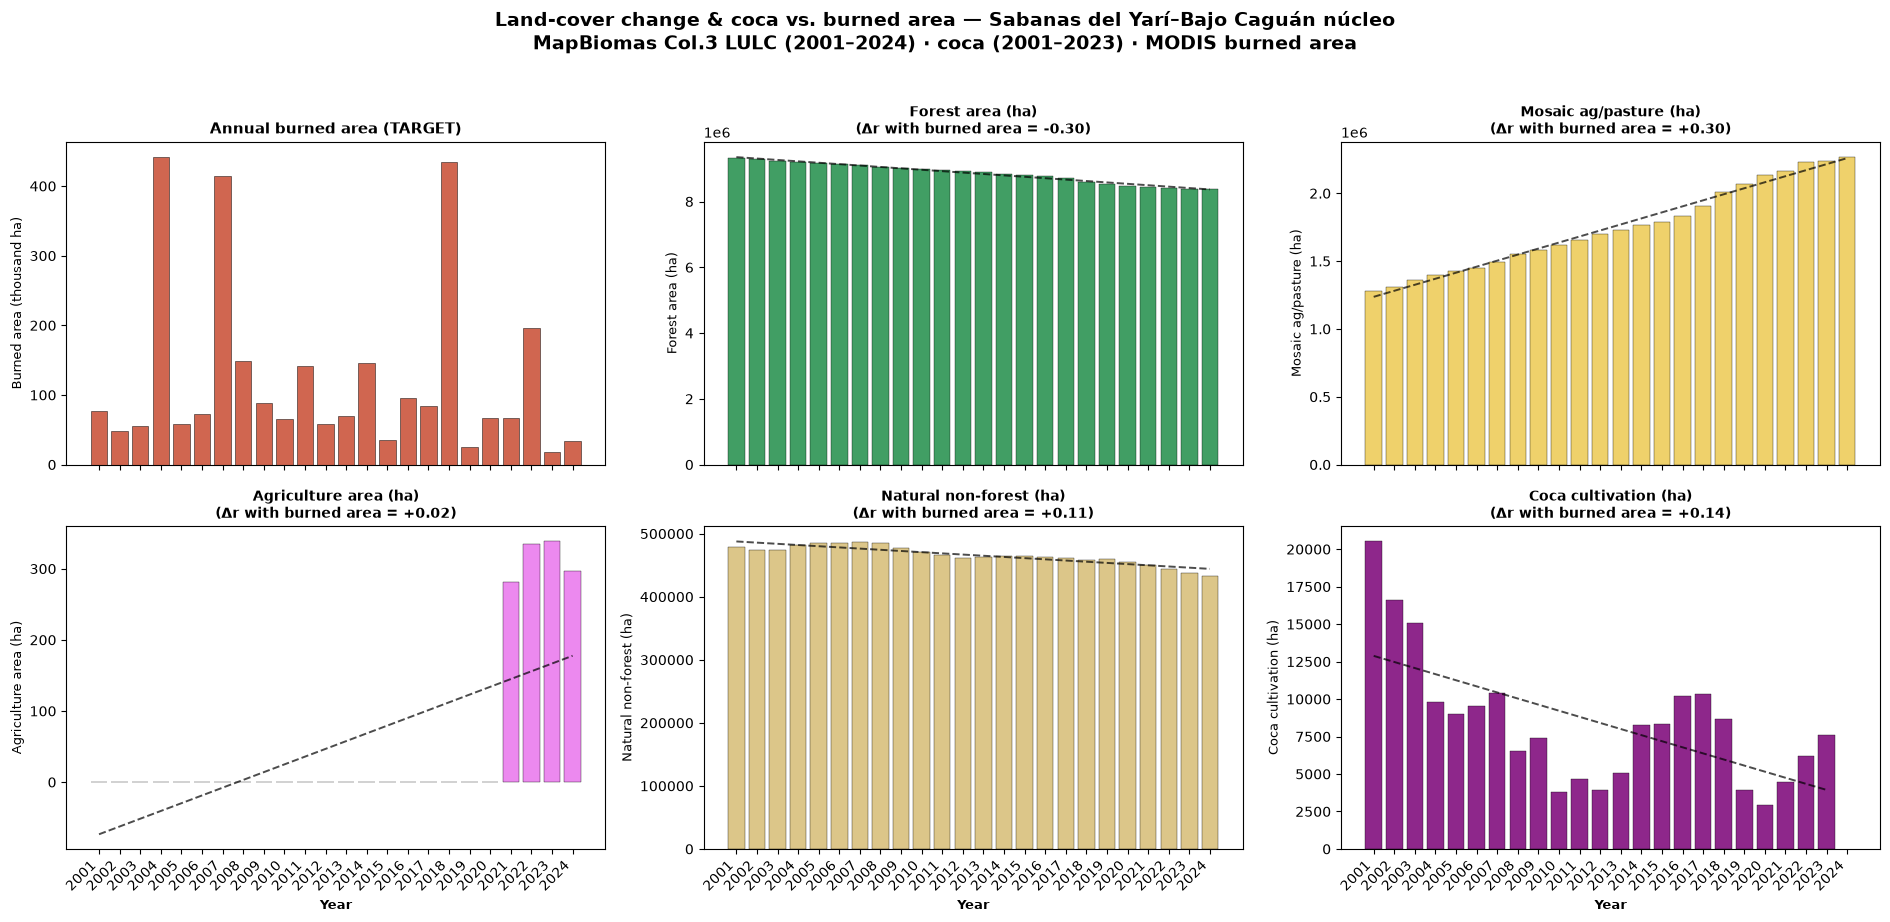

In [26]:
import matplotlib.pyplot as plt
import numpy as np

m = burned_df.merge(lulc_area_df, on='year').merge(coca_df, on='year', how='left').sort_values('year')

panels = [('forest_ha','Forest area (ha)','#1f8d49'),
          ('mosaic_ha','Mosaic ag/pasture (ha)','#edc951'),
          ('agriculture_ha','Agriculture area (ha)','#e974ed'),
          ('natural_nonforest_ha','Natural non-forest (ha)','#d6bc74'),
          ('coca_ha','Coca cultivation (ha)','#7a0177')]
panels = [(c,l,col) for c,l,col in panels if c in m.columns]

fig, axes = plt.subplots(2, 3, figsize=(19, 9), sharex=True)
axes = axes.flatten()

# Panel 0: burned area (target) as bars
axes[0].bar(m['year'], m['burned_area_ha']/1000, color='#C84B31',
            edgecolor='black', linewidth=0.4, alpha=0.85)
axes[0].set_title('Annual burned area (TARGET)', fontsize=10.5, fontweight='bold')
axes[0].set_ylabel('Burned area (thousand ha)', fontsize=9)

# Panels 1+: each LULC class / coca as bars, with a dashed trend line
for ax, (col, label, color) in zip(axes[1:], panels):
    sub = m[['year', col]].dropna()
    ax.bar(sub['year'], sub[col], color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
    if len(sub) > 2:                                            # linear trend
        z = np.polyfit(sub['year'], sub[col], 1)
        ax.plot(sub['year'], np.poly1d(z)(sub['year']), color='black',
                linewidth=1.4, linestyle='--', alpha=0.7)
    r_diff = m['burned_area_ha'].diff().corr(m[col].diff())
    ax.set_title(f'{label}\n(Δr with burned area = {r_diff:+.2f})', fontsize=10, fontweight='bold')
    ax.set_ylabel(label, fontsize=9)

for ax in axes[len(panels)+1:]:                                # hide unused panels
    ax.axis('off')
for ax in axes[3:]:
    ax.set_xticks(m['year']); ax.tick_params(labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('Year', fontsize=9, fontweight='bold')

fig.suptitle('Land-cover change & coca vs. burned area — Sabanas del Yarí–Bajo Caguán núcleo\n'
             'MapBiomas Col.3 LULC (2001–2024) · coca (2001–2023) · MODIS burned area',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../datasets/lulc_coca_bars.png', dpi=200, bbox_inches='tight')
plt.show()